## Deep dive: N-BaIoT × Kitsune (แขนงไซเบอร์)

1. **มองลึกเข้าไปในโครงสร้างข้อมูล** — PCA แยกตามอุปกรณ์/สถานการณ์ ความสามารถแยกแยะ benign/attack รายอุปกรณ์
2. **ทดลองจริงเบื้องต้น** — ฝึกโมเดลจริงและวัดตัวเลขจริง ไม่ใช่แค่คาดการณ์จากทฤษฎี:
   - **leave-one-device-out** บน N-BaIoT ครบทั้ง 9 รอบ (กันอุปกรณ์หนึ่งไว้ไม่ให้เห็นตอนเทรน)
   - **ทดสอบข้าม dataset จริง** — เทรนจาก N-BaIoT ทั้งหมด แล้ววัดกับ Kitsune ทั้ง 9 สถานการณ์

## Dataset

| ชุดข้อมูล | ที่มา | เปเปอร์ |
|---|---|---|
| N-BaIoT | [UCI ML Repository](https://archive.ics.uci.edu/dataset/442/detection_of_iot_botnet_attacks_n_baiot) | Meidan et al., *N-BaIoT: Network-based Detection of IoT Botnet Attacks Using Deep Autoencoders*, IEEE Pervasive Computing, 2018 |
| Kitsune | [Mendeley Data](https://data.mendeley.com/datasets/zvsk3k9cf2/1) · [Kaggle mirror](https://www.kaggle.com/datasets/ymirsky/network-attack-dataset-kitsune) | Mirsky et al., *Kitsune: An Ensemble of Autoencoders for Online Network Intrusion Detection*, NDSS 2018 |

In [1]:
from pathlib import Path
import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA

In [2]:
DATA = next((c for c in (Path("data"), Path("Finding Dataset/data"),
                         Path("poc/Finding Dataset/data"), Path("../data"))
             if c.is_dir()), Path("data"))

NBAIOT_ZIP = DATA / "nbaiot.zip"
KITSUNE_ZIP = DATA / "kitsune.zip"

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948", "grey": "#8a938f"}
PALETTE = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["violet"],
           C["red"], "#00c2c2", "#b5651d", "#6b8e23"]

installed = {f.name for f in font_manager.fontManager.ttflist}
THAI_FONT = next((n for n in ("Sarabun", "Thonburi", "Ayuthaya") if n in installed), "DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": [THAI_FONT], "axes.titleweight": "bold", "axes.unicode_minus": False,
})

RNG = np.random.default_rng(42)

def read_zip_csv(zf: zipfile.ZipFile, name: str, **kwargs) -> pd.DataFrame:
    """อ่าน CSV ตรงจากภายใน .zip โดยไม่แตกไฟล์ลงดิสก์ — nrows ยังช่วยประหยัดเวลาถอดรหัสได้บางส่วน"""
    with zf.open(name) as fh:
        return pd.read_csv(fh, **kwargs)

nb_zip = zipfile.ZipFile(NBAIOT_ZIP)
kit_zip = zipfile.ZipFile(KITSUNE_ZIP)
print(f"N-BaIoT zip: {len(nb_zip.namelist())} entries")
print(f"Kitsune zip: {len(kit_zip.namelist())} entries")

N-BaIoT zip: 36 entries
Kitsune zip: 28 entries


---

## N-BaIoT

In [3]:
nb_names_all = nb_zip.namelist()

devices = sorted({
    name.split("/", 1)[0]
    for name in nb_names_all
    if "/" in name
    and name.endswith(("benign_traffic.csv", ".rar"))
})

device_inventory = []

for device in devices:
    device_files = sorted(
        name for name in nb_names_all
        if name.startswith(f"{device}/")
    )

    benign_files = [
        Path(name).name
        for name in device_files
        if name.endswith("benign_traffic.csv")
    ]

    attack_files = [
        Path(name).name
        for name in device_files
        if name.endswith(".rar")
    ]

    device_inventory.append({
        "device": device,
        "benign_file": ", ".join(benign_files) or "-",
        "attack_archives": ", ".join(attack_files) or "-",
        "attack_types": ", ".join(
            Path(name).stem.replace("_attacks", "")
            for name in device_files
            if name.endswith(".rar")
        ) or "-",
    })

In [4]:
import subprocess
import tempfile
import shutil

BENIGN_PER_DEVICE = 1200
ATTACK_PER_FILE = 260


def count_csv_rows(path: Path) -> int:
    """นับจำนวนแถวจริง โดยไม่โหลดไฟล์ทั้งหมดเข้า memory"""
    with path.open("rb") as fh:
        return max(0, sum(1 for _ in fh) - 1)


def process_device(device: str) -> tuple[list[dict], pd.DataFrame]:
    """แตกไฟล์โจมตีชั่วคราว แล้วคืน inventory และตัวอย่างข้อมูล"""

    inventory, frames = [], []

    # Benign
    benign_name = f"{device}/benign_traffic.csv"

    with nb_zip.open(benign_name) as fh:
        benign_rows = max(0, sum(1 for _ in fh) - 1)

    inventory.append({
        "device": device,
        "family": "benign",
        "attack": "benign",
        "rows": benign_rows,
    })

    benign_sample = read_zip_csv(
        nb_zip,
        benign_name,
        nrows=BENIGN_PER_DEVICE,
    )
    benign_sample["label"] = 0
    benign_sample["device"] = device
    frames.append(benign_sample)

    # Attack
    with tempfile.TemporaryDirectory() as tmp:
        tmp_path = Path(tmp)

        for family in ("gafgyt", "mirai"):
            rar_name = f"{device}/{family}_attacks.rar"

            if rar_name not in nb_names_all:
                continue

            rar_path = tmp_path / f"{family}.rar"

            with nb_zip.open(rar_name) as src, rar_path.open("wb") as dst:
                shutil.copyfileobj(src, dst)

            extract_dir = tmp_path / family
            extract_dir.mkdir()

            subprocess.run(
                ["bsdtar", "-xf", str(rar_path), "-C", str(extract_dir)],
                check=True,
                capture_output=True,
            )

            for csv_file in sorted(extract_dir.glob("*.csv")):
                attack_rows = count_csv_rows(csv_file)

                inventory.append({
                    "device": device,
                    "family": family,
                    "attack": csv_file.stem,
                    "rows": attack_rows,
                })

                attack_sample = pd.read_csv(
                    csv_file,
                    nrows=ATTACK_PER_FILE,
                )
                attack_sample["label"] = 1
                attack_sample["device"] = device
                frames.append(attack_sample)

    return inventory, pd.concat(frames, ignore_index=True)


# ประมวลผลทุกอุปกรณ์
all_inventory = []
nb_samples = {}

print("กำลังอ่านข้อมูล N-BaIoT...\n")

for device in devices:
    inventory, sample = process_device(device)

    all_inventory.extend(inventory)
    nb_samples[device] = sample

    print(f"✓ {device:<22} {len(sample):>7,} แถวตัวอย่าง")


# รวมผลลัพธ์
nb_inventory = pd.DataFrame(all_inventory)
nb_all = pd.concat(nb_samples.values(), ignore_index=True)

FEATURE_COLS = [
    column for column in nb_all.columns
    if column not in ("label", "device")
]


# ตารางจำนวนข้อมูลจริงแยกตามอุปกรณ์และประเภท
actual_summary = (
    nb_inventory
    .pivot_table(
        index="device",
        columns="family",
        values="rows",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

for column in ("benign", "gafgyt", "mirai"):
    if column not in actual_summary.columns:
        actual_summary[column] = 0

actual_summary["total"] = actual_summary[
    ["benign", "gafgyt", "mirai"]
].sum(axis=1)

actual_summary = actual_summary[
    ["device", "benign", "gafgyt", "mirai", "total"]
]


# ตารางจำนวนตัวอย่างที่นำไปทดลอง
sample_summary = (
    nb_all
    .assign(
        class_name=nb_all["label"].map({
            0: "benign",
            1: "attack",
        })
    )
    .pivot_table(
        index="device",
        columns="class_name",
        values="label",
        aggfunc="size",
        fill_value=0,
    )
    .reset_index()
)

for column in ("benign", "attack"):
    if column not in sample_summary.columns:
        sample_summary[column] = 0

sample_summary["sample_total"] = (
    sample_summary["benign"] +
    sample_summary["attack"]
)

sample_summary = sample_summary[
    ["device", "benign", "attack", "sample_total"]
]


# สรุปภาพรวม
print("\nสรุปข้อมูลจริงทั้งหมด")
display(
    actual_summary.style
    .format({
        "benign": "{:,.0f}",
        "gafgyt": "{:,.0f}",
        "mirai": "{:,.0f}",
        "total": "{:,.0f}",
    })
    .set_caption("จำนวนแถวจริงใน N-BaIoT แยกตามอุปกรณ์")
    .hide(axis="index")
)

print("สรุปตัวอย่างที่ใช้ในการทดลอง")
display(
    sample_summary.style
    .format({
        "benign": "{:,.0f}",
        "attack": "{:,.0f}",
        "sample_total": "{:,.0f}",
    })
    .set_caption("จำนวนตัวอย่างที่อ่านมาใช้ทดลอง")
    .hide(axis="index")
)

print(
    f"รวมข้อมูลจริงทั้งหมด: {nb_inventory['rows'].sum():,} แถว"
)
print(
    f"ตัวอย่างที่ใช้ทดลอง: {len(nb_all):,} แถว"
)
print(
    f"จำนวนฟีเจอร์: {len(FEATURE_COLS)}"
)

กำลังอ่านข้อมูล N-BaIoT...



/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  benign_sample["label"] = 0
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  benign_sample["device"] = device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  attack_sample["label"] = 1
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  attack_sample["device"] = device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:80: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  attack_sample["label"] = 1
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  attack_sample["device"] = device


✓ Danmini_Doorbell         3,800 แถวตัวอย่าง


...

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3813608567.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(


device,benign,gafgyt,mirai,total
Danmini_Doorbell,"49,548","316,650","652,100","1,018,298"
Ecobee_Thermostat,"13,113","310,630","512,133","835,876"
Ennio_Doorbell,"39,100","316,400",0,"355,500"
Philips_B120N10_Baby_Monitor,"175,240","312,723","610,714","1,098,677"
Provision_PT_737E_Security_Camera,"62,154","330,096","436,010","828,260"
Provision_PT_838_Security_Camera,"98,514","309,040","429,337","836,891"
Samsung_SNH_1011_N_Webcam,"52,150","323,072",0,"375,222"
SimpleHome_XCS7_1002_WHT_Security_Camera,"46,585","303,223","513,248","863,056"
SimpleHome_XCS7_1003_WHT_Security_Camera,"19,528","316,438","514,860","850,826"


สรุปตัวอย่างที่ใช้ในการทดลอง


device,benign,attack,sample_total
Danmini_Doorbell,"1,200","2,600","3,800"
Ecobee_Thermostat,"1,200","2,600","3,800"
Ennio_Doorbell,"1,200","1,300","2,500"
Philips_B120N10_Baby_Monitor,"1,200","2,600","3,800"
Provision_PT_737E_Security_Camera,"1,200","2,600","3,800"
Provision_PT_838_Security_Camera,"1,200","2,600","3,800"
Samsung_SNH_1011_N_Webcam,"1,200","1,300","2,500"
SimpleHome_XCS7_1002_WHT_Security_Camera,"1,200","2,600","3,800"
SimpleHome_XCS7_1003_WHT_Security_Camera,"1,200","2,600","3,800"


รวมข้อมูลจริงทั้งหมด: 7,062,606 แถว
ตัวอย่างที่ใช้ทดลอง: 31,600 แถว
จำนวนฟีเจอร์: 115


In [5]:
per_device = (nb_inventory.pivot_table(index="device", columns="family", values="rows",
                                       aggfunc="sum", fill_value=0)
              .assign(total=lambda d: d.sum(axis=1)))
per_device["attack_share"] = (1 - per_device.get("benign", 0) / per_device["total"]).round(3)
per_device = per_device.sort_values("total", ascending=False)
per_device

family,benign,gafgyt,mirai,total,attack_share
device,,,,,
Philips_B120N10_Baby_Monitor,175240,312723,610714,1098677,0.840
Danmini_Doorbell,49548,316650,652100,1018298,0.951
SimpleHome_XCS7_1002_WHT_Security_Camera,46585,303223,513248,863056,0.946
SimpleHome_XCS7_1003_WHT_Security_Camera,19528,316438,514860,850826,0.977
Provision_PT_838_Security_Camera,98514,309040,429337,836891,0.882
Ecobee_Thermostat,13113,310630,512133,835876,0.984
Provision_PT_737E_Security_Camera,62154,330096,436010,828260,0.925
Samsung_SNH_1011_N_Webcam,52150,323072,0,375222,0.861
Ennio_Doorbell,39100,316400,0,355500,0.890


`pcc` ย่อมาจาก Pearson Correlation Coefficient หรือ ค่าสัมประสิทธิ์สหสัมพันธ์เพียร์สัน

ใช้วัดความสัมพันธ์เชิงเส้นระหว่างข้อมูล 2 ชุด:
- 1 = แปรผันไปในทิศทางเดียวกันอย่างสมบูรณ์
- 0 = แทบไม่มีความสัมพันธ์เชิงเส้น
- -1 = แปรผกผันกันอย่างสมบูรณ์

ใน Dataset นี้ คอลัมน์ที่ลงท้ายด้วย _pcc คือฟีเจอร์ที่พยายามวัดความสัมพันธ์ระหว่างคุณลักษณะของทราฟฟิก เช่น ค่าเฉลี่ยหรืออัตราการรับส่งข้อมูล



In [6]:
# ตรวจสอบข้อมูลก่อน clean
pcc_cols = [
    column for column in FEATURE_COLS
    if column.endswith("_pcc")
]

print("สรุปข้อมูลก่อน clean")
print(f"จำนวนแถว: {len(nb_all):,}")
print(f"จำนวนฟีเจอร์: {len(FEATURE_COLS)}")
print(f"จำนวนคอลัมน์ pcc: {len(pcc_cols)}")

# ตรวจค่า pcc ที่อยู่นอกช่วง [-1, 1]
pcc_before = pd.DataFrame({
    "min": nb_all[pcc_cols].min(),
    "max": nb_all[pcc_cols].max(),
    "out_of_range": (
        (nb_all[pcc_cols] < -1) |
        (nb_all[pcc_cols] > 1)
    ).sum(),
})

print("\nคอลัมน์ pcc ก่อน clip")
display(
    pcc_before
    .sort_values("out_of_range", ascending=False)
    .style.format({
        "min": "{:.4f}",
        "max": "{:.4f}",
        "out_of_range": "{:,.0f}",
    })
)

# clip ค่า pcc ที่หลุดช่วงจริง ห่อเป็นฟังก์ชันเพื่อให้เซลล์ถัดไปเรียกซ้ำได้กับ dataframe อื่น (Kitsune ด้วย)
def clip_pcc_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    out = df.copy()
    pcc = [c for c in cols if c.endswith("_pcc")]
    out[pcc] = out[pcc].clip(-1, 1)
    return out

nb_all = clip_pcc_columns(nb_all, FEATURE_COLS)
print(f"\nclip แล้ว {len(pcc_cols)} คอลัมน์ pcc ให้อยู่ในช่วง [-1, 1]")


สรุปข้อมูลก่อน clean
จำนวนแถว: 31,600
จำนวนฟีเจอร์: 115
จำนวนคอลัมน์ pcc: 10

คอลัมน์ pcc ก่อน clip


,min,max,out_of_range
HH_L0.01_pcc,-1.6914,1.5510,959
HpHp_L0.01_pcc,-1.6914,1.1782,796
HH_L0.1_pcc,-1.5865,1.2414,508
HpHp_L0.1_pcc,-1.5865,1.1641,476
HH_L1_pcc,-1.2722,1.2709,13
HpHp_L1_pcc,-1.2722,1.1000,13
HH_L3_pcc,-0.6709,1.0646,5
HH_L5_pcc,-0.6923,0.9484,0
HpHp_L5_pcc,-0.6939,0.9484,0
HpHp_L3_pcc,-0.8943,0.9773,0



clip แล้ว 10 คอลัมน์ pcc ให้อยู่ในช่วง [-1, 1]


## PCA, ข้อมูลของแต่ละอุปกรณ์แยกกันเป็นกลุ่มชัดแค่ไหน

ย่อ 115 ฟีเจอร์เหลือ 2 มิติด้วย PCA (fit บนข้อมูลรวมทุกอุปกรณ์) แล้ววาดจุดแยกสี — ถ้าอุปกรณ์แต่ละตัว
รวมกลุ่มกันชัดเจน แปลว่าข้อมูลของอุปกรณ์นั้น **มีลักษณะเฉพาะตัวจริง** ไม่ใช่แค่สุ่มมาจากกองเดียวกัน
ซึ่งเป็นหลักฐานภาพที่สนับสนุนว่า "1 อุปกรณ์ = 1 หน่วยงาน" มีความหมายจริง ไม่ใช่แค่ป้ายกำกับ

In [7]:
X = nb_all[FEATURE_COLS].to_numpy(dtype=float)
scaler_viz = StandardScaler().fit(X)
Xz = scaler_viz.transform(X)

pca = PCA(n_components=10, random_state=42).fit(Xz)
Xp = pca.transform(Xz)

explained = pca.explained_variance_ratio_
n95 = int(np.searchsorted(np.cumsum(explained), 0.95) + 1)
print(f"2 มิติแรกอธิบายความแปรปรวนได้ {explained[:2].sum():.1%}")
print(f"ต้องใช้ {n95} มิติ (จาก 115) เพื่ออธิบาย 95% ของความแปรปรวน — สอดคล้องกับที่พบว่า "
      f"96/115 คอลัมน์ซ้ำซ้อนกันสูงใน Explore.ipynb")

2 มิติแรกอธิบายความแปรปรวนได้ 47.5%
ต้องใช้ 11 มิติ (จาก 115) เพื่ออธิบาย 95% ของความแปรปรวน — สอดคล้องกับที่พบว่า 96/115 คอลัมน์ซ้ำซ้อนกันสูงใน Explore.ipynb


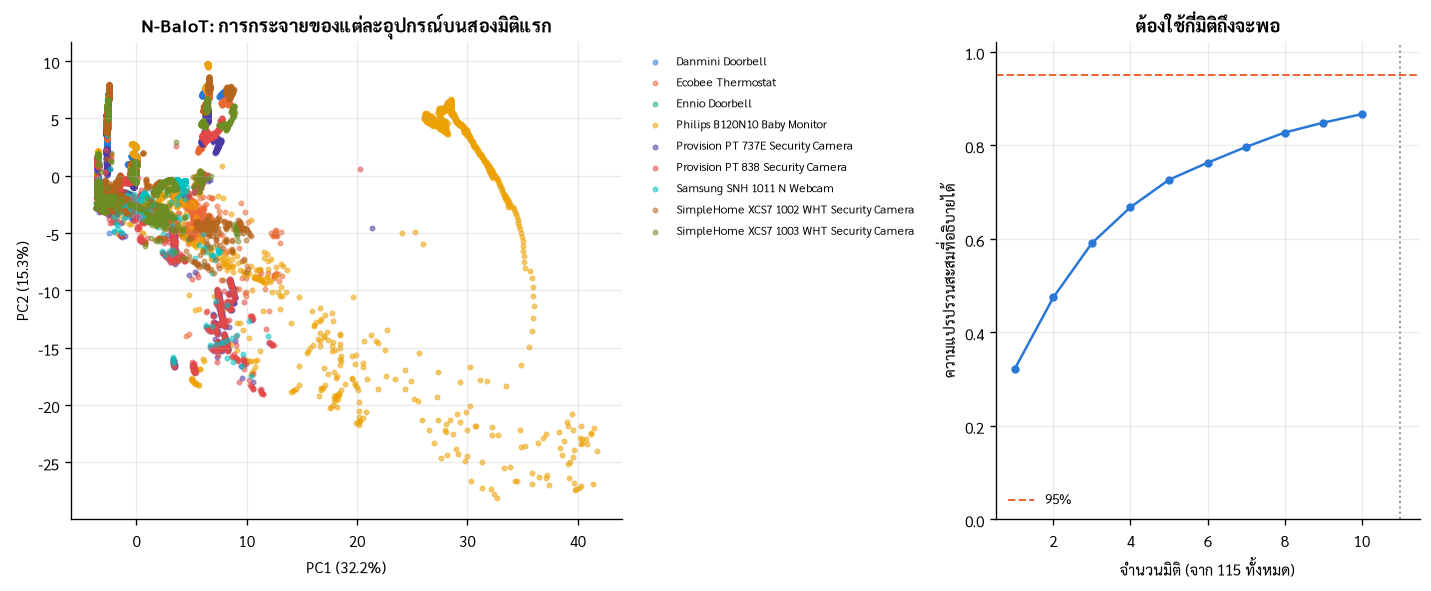

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.3, 1]})

for i, device in enumerate(devices):
    mask = (nb_all["device"] == device).to_numpy()
    ax1.scatter(Xp[mask, 0], Xp[mask, 1], s=7, alpha=0.5, color=PALETTE[i % len(PALETTE)],
               label=device.replace("_", " "))
ax1.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax1.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax1.set_title("N-BaIoT: การกระจายของแต่ละอุปกรณ์บนสองมิติแรก")
ax1.legend(frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))

ax2.plot(range(1, 11), np.cumsum(explained), marker="o", color=C["blue"], markersize=4)
ax2.axhline(0.95, color=C["orange"], linestyle="--", linewidth=1.2, label="95%")
ax2.axvline(n95, color=C["grey"], linestyle=":", linewidth=1.2)
ax2.set_xlabel("จำนวนมิติ (จาก 115 ทั้งหมด)")
ax2.set_ylabel("ความแปรปรวนสะสมที่อธิบายได้")
ax2.set_title("ต้องใช้กี่มิติถึงจะพอ")
ax2.legend(frameon=False, fontsize=8)
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

## 1.5 แต่ละอุปกรณ์แยก benign/attack ได้ยากง่ายแค่ไหน (baseline ภายในอุปกรณ์เดียว)

ก่อนจะไปถึง leave-one-device-out ลองดูก่อนว่าถ้าเทรน-ทดสอบภายในอุปกรณ์เดียวกัน (แบ่ง 70/30)
โมเดลง่าย ๆ แยกได้ดีแค่ไหน — นี่คือเพดานบนคร่าว ๆ ที่ leave-one-device-out ไม่ควรเกิน

In [9]:
from sklearn.model_selection import train_test_split

within_device_rows = []
for device in devices:
    df = nb_samples[device].pipe(clip_pcc_columns, FEATURE_COLS)
    X, y = df[FEATURE_COLS].to_numpy(dtype=float), df["label"].to_numpy()
    if y.sum() == 0 or y.sum() == len(y):
        continue
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
    pred = clf.predict(sc.transform(Xte))
    within_device_rows.append({"device": device, "test_rows": len(yte),
                               "accuracy": round(accuracy_score(yte, pred), 4),
                               "f1": round(f1_score(yte, pred), 4)})

within_device = pd.DataFrame(within_device_rows).sort_values("accuracy")
within_device

,device,test_rows,accuracy,f1
7,SimpleHome_XCS7_1002_WHT_Security_Camera,1140,0.9886,0.9917
5,Provision_PT_838_Security_Camera,1140,0.9904,0.9930
2,Ennio_Doorbell,750,0.9907,0.9911
4,Provision_PT_737E_Security_Camera,1140,0.9912,0.9936
0,Danmini_Doorbell,1140,0.9947,0.9962
1,Ecobee_Thermostat,1140,0.9956,0.9968
3,Philips_B120N10_Baby_Monitor,1140,0.9965,0.9974
6,Samsung_SNH_1011_N_Webcam,750,0.9973,0.9974
8,SimpleHome_XCS7_1003_WHT_Security_Camera,1140,0.9991,0.9994


เกือบทุกอุปกรณ์แยก benign/attack ภายในตัวเองได้เกือบสมบูรณ์แบบ ซึ่งคาดไว้แล้ว — งานยากจริง ๆ
ไม่ใช่การแยกแยะภายในอุปกรณ์เดียว แต่คือ **การเอาความรู้จากอุปกรณ์อื่นมาใช้กับอุปกรณ์ที่ไม่เคยเห็น**
ซึ่งเป็นสิ่งที่ทดลองต่อไปนี้วัด

---

## 1.6 Leave-one-device-out — ทดลองจริง ครบทั้ง 9 รอบ

นี่คือแกนหลักของโน้ตบุ๊กนี้ ทำตามแผนที่วางไว้ใน dataset-selection: กันอุปกรณ์หนึ่งไว้ไม่ให้โมเดลเห็นเลย
เทรนจากอีก 8 อุปกรณ์ที่เหลือ (pool ข้อมูลรวมกัน) แล้ววัดผลกับอุปกรณ์ที่กันไว้ ทำวนครบทั้ง 9 ตัว

**กติกาสำคัญ:** ตัวปรับสเกล (`StandardScaler`) fit จากอุปกรณ์ฝึกเท่านั้น ห้ามใช้ข้อมูลอุปกรณ์ทดสอบมาคำนวณ
ไม่งั้นเท่ากับแอบดูเฉลย

In [10]:
def run_loo(devices_list, samples: dict, model_factory) -> pd.DataFrame:
    rows = []
    for held_out in devices_list:
        train_devices = [d for d in devices_list if d != held_out]
        train_df = pd.concat([samples[d] for d in train_devices], ignore_index=True)
        test_df = samples[held_out]

        train_df = clip_pcc_columns(train_df, FEATURE_COLS)
        test_df = clip_pcc_columns(test_df, FEATURE_COLS)

        Xtr = train_df[FEATURE_COLS].to_numpy(dtype=float)
        ytr = train_df["label"].to_numpy()
        Xte = test_df[FEATURE_COLS].to_numpy(dtype=float)
        yte = test_df["label"].to_numpy()

        scaler = StandardScaler().fit(Xtr)          # fit บนฝั่งเทรนเท่านั้น
        clf = model_factory().fit(scaler.transform(Xtr), ytr)
        pred = clf.predict(scaler.transform(Xte))
        proba = clf.predict_proba(scaler.transform(Xte))[:, 1]

        rows.append({
            "held_out_device": held_out,
            "train_rows": len(ytr), "test_rows": len(yte),
            "test_benign": int((yte == 0).sum()), "test_attack": int((yte == 1).sum()),
            "accuracy": round(accuracy_score(yte, pred), 4),
            "f1": round(f1_score(yte, pred), 4),
            "auc": round(roc_auc_score(yte, proba), 4) if len(set(yte)) > 1 else np.nan,
        })
    return pd.DataFrame(rows)

loo_results = run_loo(devices, nb_samples,
                      lambda: RandomForestClassifier(n_estimators=150, max_depth=12,
                                                      n_jobs=-1, random_state=42))
loo_results.sort_values("accuracy")

,held_out_device,train_rows,test_rows,test_benign,test_attack,accuracy,f1,auc
3,Philips_B120N10_Baby_Monitor,27800,3800,1200,2600,0.8597,0.9070,1.0
4,Provision_PT_737E_Security_Camera,27800,3800,1200,2600,0.9871,0.9905,1.0
8,SimpleHome_XCS7_1003_WHT_Security_Camera,27800,3800,1200,2600,0.9989,0.9992,1.0
2,Ennio_Doorbell,29100,2500,1200,1300,0.9996,0.9996,1.0
7,SimpleHome_XCS7_1002_WHT_Security_Camera,27800,3800,1200,2600,0.9997,0.9998,1.0
0,Danmini_Doorbell,27800,3800,1200,2600,1.0000,1.0000,1.0
1,Ecobee_Thermostat,27800,3800,1200,2600,1.0000,1.0000,1.0
5,Provision_PT_838_Security_Camera,27800,3800,1200,2600,1.0000,1.0000,1.0
6,Samsung_SNH_1011_N_Webcam,29100,2500,1200,1300,1.0000,1.0000,1.0


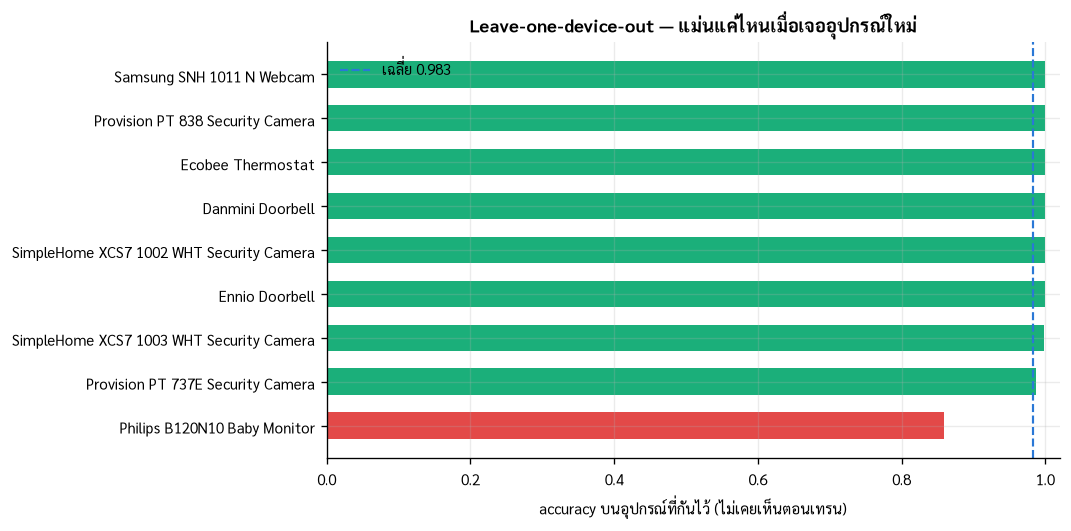

accuracy เฉลี่ยภายในอุปกรณ์เดียว (1.6): 0.9938
accuracy เฉลี่ยแบบ leave-one-device-out:  0.9828
ส่วนต่าง (generalization gap): 0.0110


In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = loo_results.sort_values("accuracy")
colors = [C["red"] if a < 0.9 else (C["orange"] if a < 0.97 else C["aqua"]) for a in order["accuracy"]]
ax.barh(order["held_out_device"].str.replace("_", " "), order["accuracy"], color=colors, height=0.6)
ax.axvline(loo_results["accuracy"].mean(), color=C["blue"], linestyle="--", linewidth=1.3,
          label=f"เฉลี่ย {loo_results['accuracy'].mean():.3f}")
ax.set_xlim(0, 1.02)
ax.set_xlabel("accuracy บนอุปกรณ์ที่กันไว้ (ไม่เคยเห็นตอนเทรน)")
ax.set_title("Leave-one-device-out — แม่นแค่ไหนเมื่อเจออุปกรณ์ใหม่")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

gap = within_device["accuracy"].mean() - loo_results["accuracy"].mean()
print(f"accuracy เฉลี่ยภายในอุปกรณ์เดียว (1.6): {within_device['accuracy'].mean():.4f}")
print(f"accuracy เฉลี่ยแบบ leave-one-device-out:  {loo_results['accuracy'].mean():.4f}")
print(f"ส่วนต่าง (generalization gap): {gap:.4f}")

### อ่านผล

ส่วนต่างระหว่างสองบรรทัดสุดท้ายคือ **ราคาที่ต้องจ่ายจริงเมื่อโมเดลต้องเจออุปกรณ์ที่ไม่เคยเห็น**
ถ้าส่วนต่างนี้เล็ก แปลว่าความรู้ที่เรียนจากอุปกรณ์หนึ่งถ่ายไปอุปกรณ์อื่นได้ดี — ตรงข้ามกับ
"ท่องจำ" ลักษณะเฉพาะของแต่ละอุปกรณ์ ถ้าส่วนต่างใหญ่ แปลว่าแต่ละอุปกรณ์มีลายเซ็นทราฟฟิกเฉพาะตัวสูง
สอดคล้องกับที่เห็นใน PCA ข้อ 1.5

อุปกรณ์ที่ได้ accuracy ต่ำสุดในกราฟคืออุปกรณ์ที่ "แปลกแยก" จากอีกแปดตัวมากที่สุด — น่าจะตรงกับ
ตัวที่อยู่ไกลออกไปในแผนภาพ PCA ก่อนหน้า

---

# ส่วนที่ 2 · Kitsune

## 2.1 โครงสร้างไฟล์และจำนวนที่ประกาศไว้ (จาก `Dataset Properties.csv` ในชุดเอง)

In [12]:
kit_names = [n for n in kit_zip.namelist() if n.endswith(".csv")]
kit_root = next(n for n in kit_zip.namelist() if n.endswith("Dataset Properties.csv"))
properties = read_zip_csv(kit_zip, kit_root)
scenarios = sorted({n.split("/")[1] for n in kit_names if "Dataset Properties" not in n})
print(f"{len(scenarios)} สถานการณ์: {scenarios}")
properties

9 สถานการณ์: ['ARP', 'Fuzzing', 'Mirai', 'OS Scan', 'SSDP F', 'SSL R', 'SYN DoS', 'Video Inj', 'Wiretap']


,Attack,# training packets,# normal test packets,# malicious test packets
0,OS Scan,6000,13500,1499
1,Fuzzing,1200,9000,999
2,Video Inj.,4000,9000,999
3,ARP,6000,13500,1499
4,Wiretap,4000,9000,999
5,SSDP F.,6000,13500,1499
6,SYN DoS,1200,9000,999
7,SSL R.,6000,13500,1499
8,Mirai,6000,9000,999


## 2.2 โหลดตัวอย่าง (แก้ปัญหาคอลัมน์เกินของไฟล์ Mirai ตามที่พบใน `Explore.ipynb`)

In [13]:
def load_kitsune_scenario(scenario: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """คืน (train, test) — train เป็น benign ล้วน, test มีทั้ง benign และ attack"""
    prefix = f"Small versions of datasets by Mirskey et al (2018)/{scenario}"
    train = read_zip_csv(kit_zip, f"{prefix}/train.csv", header=None)
    test = read_zip_csv(kit_zip, f"{prefix}/test.csv", header=None)
    for df in (train, test):
        if df.shape[1] == 117:                 # ไฟล์ Mirai มีคอลัมน์เลขลำดับติดมา
            df.drop(columns=df.columns[0], inplace=True)
        df.columns = [*FEATURE_COLS, "label_raw"]
        df["label"] = df["label_raw"].astype(int)
        df.drop(columns="label_raw", inplace=True)
    return train, test

kit_data = {s: load_kitsune_scenario(s) for s in scenarios}
for s, (tr, te) in kit_data.items():
    print(f"{s:12s} train={len(tr):>6,} (benign ทั้งหมด)   "
          f"test={len(te):>6,} (attack {te['label'].sum():,})")

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

ARP          train= 6,000 (benign ทั้งหมด)   test=14,999 (attack 1,499)
Fuzzing      train= 1,200 (benign ทั้งหมด)   test= 9,999 (attack 999)
Mirai        train= 6,000 (benign ทั้งหมด)   test= 9,999 (attack 999)
OS Scan      train= 6,000 (benign ทั้งหมด)   test=14,999 (attack 1,499)
SSDP F       train= 6,000 (benign ทั้งหมด)   test=14,999 (attack 1,499)
SSL R        train= 6,000 (benign ทั้งหมด)   test=14,999 (attack 1,499)
SYN DoS      train= 1,200 (benign ทั้งหมด)   test= 9,999 (attack 999)
Video Inj    train= 4,000 (benign ทั้งหมด)   test= 9,999 (attack 999)
Wiretap      train= 4,000 (benign ทั้งหมด)   test= 9,999 (attack 999)


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label"] = df["label_raw"].astype(int)
/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3772459768.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

## 2.3 PCA ของ Kitsune บนพื้นที่ฟีเจอร์เดียวกับ N-BaIoT

ใช้ scaler และแกน PCA **ตัวเดียวกับที่ fit จาก N-BaIoT ในข้อ 1.5** (ไม่ fit ใหม่) เพื่อดูว่า
สถานการณ์ต่าง ๆ ของ Kitsune ตกอยู่ตรงไหนเทียบกับกลุ่มของ N-BaIoT — นี่คือการทดสอบภาพว่า
"พื้นที่ฟีเจอร์เดียวกัน" ที่พิสูจน์ไว้แล้วด้วยตัวเลข (เครื่องหมายค่าตรงกัน 20/20) เอามาใช้ได้จริงในทางปฏิบัติไหม

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/261017567.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [tr.assign(scenario=s) for s, (tr, _) in kit_data.items()], ignore_index=True


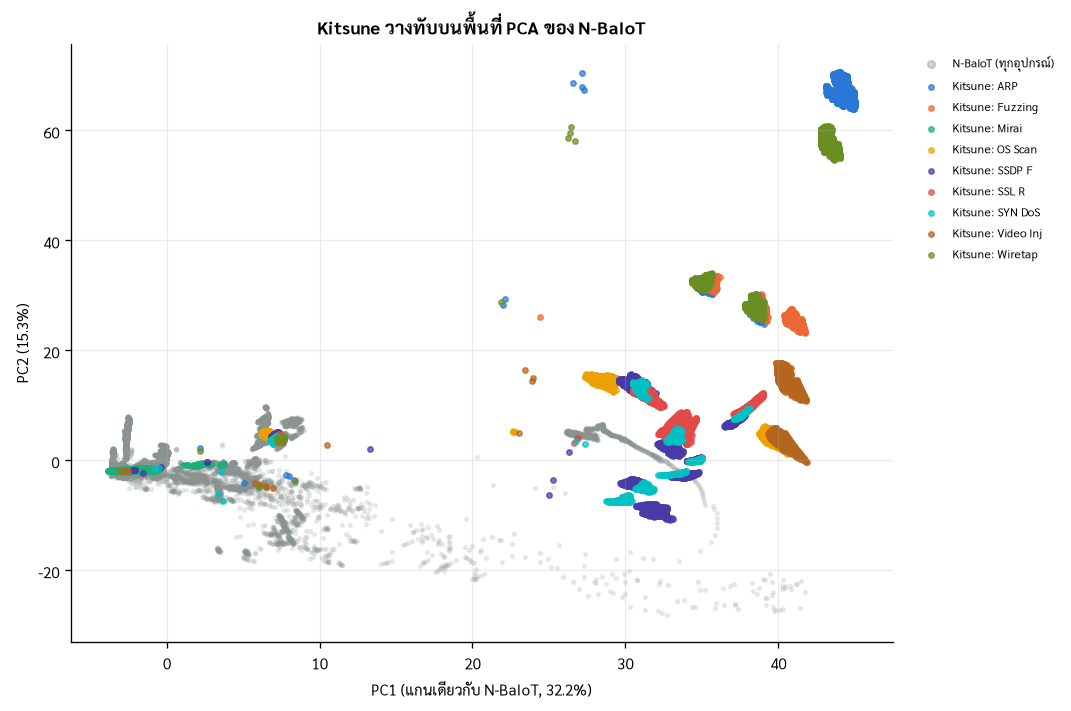

In [14]:
kit_benign_all = pd.concat(
    [tr.assign(scenario=s) for s, (tr, _) in kit_data.items()], ignore_index=True
).pipe(clip_pcc_columns, FEATURE_COLS)

Xk = kit_benign_all[FEATURE_COLS].to_numpy(dtype=float)
Xkz = scaler_viz.transform(Xk)          # scaler เดิมจาก N-BaIoT ไม่ fit ใหม่
Xkp = pca.transform(Xkz)                # PCA เดิมจาก N-BaIoT

fig, ax = plt.subplots(figsize=(9, 6))
for i, device in enumerate(devices):
    mask = (nb_all["device"] == device).to_numpy()
    ax.scatter(Xp[mask, 0], Xp[mask, 1], s=5, alpha=0.15, color=C["grey"])
ax.scatter([], [], s=20, color=C["grey"], alpha=0.4, label="N-BaIoT (ทุกอุปกรณ์)")

for i, scenario in enumerate(scenarios):
    mask = (kit_benign_all["scenario"] == scenario).to_numpy()
    ax.scatter(Xkp[mask, 0], Xkp[mask, 1], s=10, alpha=0.7, color=PALETTE[i % len(PALETTE)],
              label=f"Kitsune: {scenario}")

ax.set_xlabel(f"PC1 (แกนเดียวกับ N-BaIoT, {explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.set_title("Kitsune วางทับบนพื้นที่ PCA ของ N-BaIoT")
ax.legend(frameon=False, fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

ถ้าจุดของ Kitsune (สีสด) ตกอยู่ **นอกกลุ่มเทาของ N-BaIoT อย่างชัดเจน** ยืนยันสิ่งที่วัดไว้แล้วใน
`Explore.ipynb` ว่าค่าเชิงขนาด (weight, mean, magnitude ฯลฯ) ห่างกันเฉลี่ย 1.28 SD — ทราฟฟิกสองเครือข่าย
นี้มีปริมาณต่างกันจริง แม้จะอยู่บนพื้นที่ฟีเจอร์เดียวกันก็ตาม

---

## 2.4 ทดสอบข้าม dataset จริง — เทรนจาก N-BaIoT ทั้งหมด วัดกับ Kitsune ทุกสถานการณ์

นี่คือทดลองที่สำคัญที่สุดของโน้ตบุ๊กนี้ `Explore.ipynb` พิสูจน์แล้วว่า **ฟีเจอร์ตรงตำแหน่งกัน**
(เงื่อนไขที่ต้องผ่านก่อน) แต่ยังไม่เคยวัดว่า **โมเดลที่เทรนจริงจะทำนายข้ามชุดได้ดีแค่ไหน**
ข้อนี้ตอบคำถามนั้นด้วยตัวเลขจริง

In [15]:
nb_full_train = clip_pcc_columns(nb_all, FEATURE_COLS)
Xfull = nb_full_train[FEATURE_COLS].to_numpy(dtype=float)
yfull = nb_full_train["label"].to_numpy()

transfer_scaler = StandardScaler().fit(Xfull)     # fit จาก N-BaIoT เท่านั้น ไม่แตะ Kitsune เลย
transfer_clf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                      n_jobs=-1, random_state=42)
transfer_clf.fit(transfer_scaler.transform(Xfull), yfull)

transfer_rows = []
for scenario, (_, test) in kit_data.items():
    test_c = clip_pcc_columns(test, FEATURE_COLS)     # clip เดียวกับตอนเทรน
    Xte = test_c[FEATURE_COLS].to_numpy(dtype=float)
    yte = test_c["label"].to_numpy()

    pred = transfer_clf.predict(transfer_scaler.transform(Xte))
    proba = transfer_clf.predict_proba(transfer_scaler.transform(Xte))[:, 1]

    transfer_rows.append({
        "scenario": scenario, "test_rows": len(yte),
        "test_benign": int((yte == 0).sum()), "test_attack": int((yte == 1).sum()),
        "accuracy": round(accuracy_score(yte, pred), 4),
        "f1": round(f1_score(yte, pred), 4) if yte.sum() > 0 else np.nan,
        "auc": round(roc_auc_score(yte, proba), 4) if len(set(yte)) > 1 else np.nan,
    })

transfer_results = pd.DataFrame(transfer_rows).sort_values("accuracy")
transfer_results

,scenario,test_rows,test_benign,test_attack,accuracy,f1,auc
5,SSL R,14999,13500,1499,0.0846,0.1400,0.0435
1,Fuzzing,9999,9000,999,0.1002,0.1817,0.5318
8,Wiretap,9999,9000,999,0.1002,0.1817,0.7232
0,ARP,14999,13500,1499,0.1005,0.1818,0.5018
6,SYN DoS,9999,9000,999,0.1082,0.1684,0.0905
4,SSDP F,14999,13500,1499,0.1225,0.1627,0.1784
7,Video Inj,9999,9000,999,0.1915,0.1982,0.5366
3,OS Scan,14999,13500,1499,0.2471,0.1971,0.9031
2,Mirai,9999,9000,999,0.9007,0.0119,0.5235


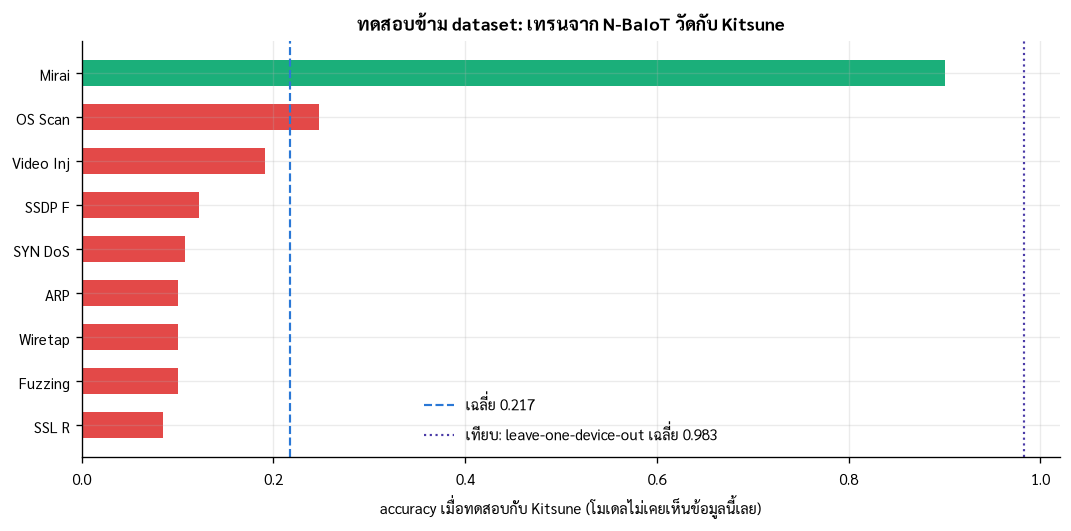

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = transfer_results.sort_values("accuracy")
colors = [C["red"] if a < 0.7 else (C["orange"] if a < 0.9 else C["aqua"]) for a in order["accuracy"]]
ax.barh(order["scenario"], order["accuracy"], color=colors, height=0.6)
ax.axvline(transfer_results["accuracy"].mean(), color=C["blue"], linestyle="--", linewidth=1.3,
          label=f"เฉลี่ย {transfer_results['accuracy'].mean():.3f}")
ax.axvline(loo_results["accuracy"].mean(), color=C["violet"], linestyle=":", linewidth=1.3,
          label=f"เทียบ: leave-one-device-out เฉลี่ย {loo_results['accuracy'].mean():.3f}")
ax.set_xlim(0, 1.02)
ax.set_xlabel("accuracy เมื่อทดสอบกับ Kitsune (โมเดลไม่เคยเห็นข้อมูลนี้เลย)")
ax.set_title("ทดสอบข้าม dataset: เทรนจาก N-BaIoT วัดกับ Kitsune")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### อ่านผล — แย่กว่าที่คาดไว้มาก และต้องอธิบายให้ตรงความจริง

ตัวเลขที่ได้จริง **ไม่ใช่** "ยังพอใช้ได้แต่แย่กว่า" ตามที่คาดไว้ตอนวางแผน แต่คือ
**accuracy เฉลี่ย 21.7% ซึ่งแย่กว่าเดาสุ่มในหลายสถานการณ์** ต้องขุดต่อว่าเกิดอะไรขึ้น

จุดที่ชวนสงสัยที่สุดคือแถว `Mirai`: accuracy สูงถึง 90.07% แต่ `f1 = 0.0119`
ตัวเลขคู่นี้ขัดกันเอง — คำอธิบายคือ **โมเดลทายว่า "benign" เกือบทุกแถวไม่ว่าอินพุตจะเป็นอะไร**
และบังเอิญ test set ของ Mirai มี benign อยู่ 90% พอดี (9,000 จาก 9,999) accuracy เลยดูสูงลอย ๆ
โดยไม่ได้แยกแยะอะไรได้จริง ส่วนสถานการณ์อื่นที่สัดส่วน benign ใกล้เคียงกันแต่ accuracy กลับต่ำเตี้ย
(10–25%) คือโมเดลทายสลับด้าน — ทายว่า "attack" เกือบทุกแถวแทน

สรุปคือ **โมเดลไม่ได้แยกแยะ benign/attack ของ Kitsune เลย มันแค่ทายไปทางใดทางหนึ่งเกือบทั้งหมด**
ทั้งที่ `Explore.ipynb` พิสูจน์แล้วว่าฟีเจอร์ตรงตำแหน่งกัน 100% คำถามคือทำไม

## 2.5 วินิจฉัย — ปัญหาคือสเกลต่างกัน หรือโครงสร้างสัญญาณต่างกันจริง

`Explore.ipynb` เคยวัดไว้ว่าค่าเชิงขนาด (weight, mean, magnitude ฯลฯ) ของสองชุดนี้ห่างกันเฉลี่ย
1.28 เท่าของส่วนเบี่ยงเบนมาตรฐาน ข้อสงสัยคือ **ตัวปรับสเกลที่ fit จาก N-BaIoT อย่างเดียว**
(ตามกติกาที่ตั้งไว้ในข้อ 1.6) อาจทำให้ค่าของ Kitsune หลุดไปไกลจากช่วงที่โมเดลเคยเห็นตอนเทรน
จนการตัดสินใจของโมเดลพังทั้งกระดาน

ทดลองเสริม: ปรับสเกล Kitsune ด้วยตัวปรับสเกลของ **ตัวเอง** (fit จาก `train.csv` ของแต่ละสถานการณ์
ซึ่งเป็น benign ล้วน) แทนที่จะใช้ตัวปรับสเกลจาก N-BaIoT แล้วป้อนเข้าโมเดลตัวเดิม (ไม่เทรนใหม่)
— เป็นเทคนิค domain adaptation อย่างง่ายที่สุด (moment matching): ถ้าวิธีนี้ทำให้ดีขึ้นมาก
แปลว่าปัญหาหลักคือสเกลไม่ตรงกัน แก้ได้ไม่ยาก แต่ถ้ายังแย่อยู่ แปลว่าปัญหาลึกกว่านั้น

In [17]:
transfer_v2_rows = []
for scenario, (train, test) in kit_data.items():
    train_c = clip_pcc_columns(train, FEATURE_COLS)
    test_c = clip_pcc_columns(test, FEATURE_COLS)

    # fit ตัวปรับสเกลจาก Kitsune เอง (เฉพาะ train ที่เป็น benign ล้วน) ไม่ใช้ตัวจาก N-BaIoT
    local_scaler = StandardScaler().fit(train_c[FEATURE_COLS].to_numpy(dtype=float))
    Xte = test_c[FEATURE_COLS].to_numpy(dtype=float)
    yte = test_c["label"].to_numpy()

    pred = transfer_clf.predict(local_scaler.transform(Xte))       # โมเดลตัวเดิม ไม่เทรนใหม่
    proba = transfer_clf.predict_proba(local_scaler.transform(Xte))[:, 1]

    transfer_v2_rows.append({
        "scenario": scenario, "test_rows": len(yte),
        "accuracy": round(accuracy_score(yte, pred), 4),
        "f1": round(f1_score(yte, pred), 4) if yte.sum() > 0 else np.nan,
        "auc": round(roc_auc_score(yte, proba), 4) if len(set(yte)) > 1 else np.nan,
    })

transfer_v2 = pd.DataFrame(transfer_v2_rows).sort_values("accuracy")
transfer_v2

,scenario,test_rows,accuracy,f1,auc
3,OS Scan,14999,0.1005,0.1805,0.4115
1,Fuzzing,9999,0.2224,0.2044,0.5236
5,SSL R,14999,0.2614,0.0107,0.1749
0,ARP,14999,0.3852,0.1932,0.4228
8,Wiretap,9999,0.4157,0.1955,0.6293
4,SSDP F,14999,0.4170,0.0005,0.4314
7,Video Inj,9999,0.4373,0.2621,0.5193
2,Mirai,9999,0.5310,0.1410,0.4818
6,SYN DoS,9999,0.5486,0.1954,0.5654


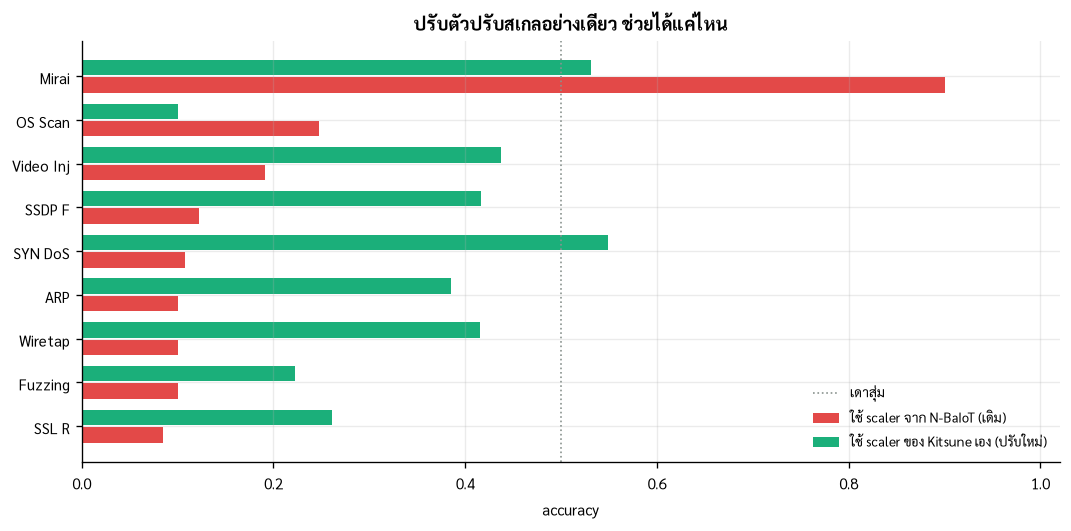

accuracy เฉลี่ย · scaler เดิมจาก N-BaIoT:  0.2173
accuracy เฉลี่ย · scaler ปรับใหม่:          0.3688
AUC เฉลี่ย · scaler เดิมจาก N-BaIoT:        0.4480
AUC เฉลี่ย · scaler ปรับใหม่:                0.4622


In [18]:
compare = (transfer_results[["scenario", "accuracy", "auc"]]
          .merge(transfer_v2[["scenario", "accuracy", "auc"]], on="scenario",
                 suffixes=("_scaler_เดิม", "_scaler_ปรับใหม่")))

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(compare))
ax.barh(y - 0.2, compare["accuracy_scaler_เดิม"], height=0.35, color=C["red"],
       label="ใช้ scaler จาก N-BaIoT (เดิม)")
ax.barh(y + 0.2, compare["accuracy_scaler_ปรับใหม่"], height=0.35, color=C["aqua"],
       label="ใช้ scaler ของ Kitsune เอง (ปรับใหม่)")
ax.axvline(0.5, color=C["grey"], linestyle=":", linewidth=1, label="เดาสุ่ม")
ax.set_yticks(y, compare["scenario"])
ax.set_xlim(0, 1.02)
ax.set_xlabel("accuracy")
ax.set_title("ปรับตัวปรับสเกลอย่างเดียว ช่วยได้แค่ไหน")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print(f"accuracy เฉลี่ย · scaler เดิมจาก N-BaIoT:  {transfer_results['accuracy'].mean():.4f}")
print(f"accuracy เฉลี่ย · scaler ปรับใหม่:          {transfer_v2['accuracy'].mean():.4f}")
print(f"AUC เฉลี่ย · scaler เดิมจาก N-BaIoT:        {transfer_results['auc'].mean():.4f}")
print(f"AUC เฉลี่ย · scaler ปรับใหม่:                {transfer_v2['auc'].mean():.4f}")

### อ่านผลข้อ 2.5

**AUC** คือตัวเลขที่ตัดปัญหา threshold ทิ้งไป (วัดว่าโมเดลจัดอันดับ attack ไว้เหนือ benign ได้ไหม
ไม่สนใจว่าจุดตัดสินใจอยู่ตรงไหน) ถ้า AUC เฉลี่ยทั้งสองแบบใกล้เคียงกันและอยู่แถว 0.5
แปลว่า**ปัญหาไม่ใช่แค่สเกล** ตัวโมเดลเองไม่ได้เรียนรู้อะไรที่ใช้แยกแยะทราฟฟิกของ Kitsune ได้เลย
ไม่ว่าจะปรับสเกลยังไง — ผิดกับกรณีที่ AUC สูงอยู่แล้วแต่ accuracy ต่ำ ซึ่งจะบอกว่าเป็นแค่ปัญหา
threshold/สเกลที่แก้ด้วยการ calibrate ใหม่ได้

ถ้า AUC ยังต่ำอยู่ทั้งสองแบบ คำอธิบายที่เป็นไปได้คือ **N-BaIoT กับ Kitsune แม้จะสกัดฟีเจอร์ด้วยสูตร
เดียวกัน (AfterImage) แต่ธรรมชาติของทราฟฟิกที่ถูกสกัดต่างกันมากพอที่ "ลายเซ็นของการโจมตี"
ที่โมเดลเรียนรู้จาก N-BaIoT ใช้ไม่ได้กับ Kitsune** — เป็นคนละสมมติฐานกับที่ตั้งไว้ตอนวางแผน
ว่า "ฟีเจอร์ตรงตำแหน่งกันแปลว่าโอนโมเดลได้เลย" ฟีเจอร์ตรงตำแหน่งกันเป็นเงื่อนไข**จำเป็น**
แต่ไม่ใช่เงื่อนไข**พอเพียง**สำหรับการโอนโมเดลข้าม dataset

---

# สรุป

In [19]:
summary = pd.DataFrame([
    {"การทดลอง": "1.5 ภายในอุปกรณ์เดียว (เพดานบน)",
     "accuracy เฉลี่ย": within_device["accuracy"].mean(),
     "จำนวนรอบ": len(within_device)},
    {"การทดลอง": "1.6 leave-one-device-out (ข้ามอุปกรณ์ ในชุดเดิม)",
     "accuracy เฉลี่ย": loo_results["accuracy"].mean(),
     "จำนวนรอบ": len(loo_results)},
    {"การทดลอง": "2.4 ทดสอบข้าม dataset · scaler จาก N-BaIoT",
     "accuracy เฉลี่ย": transfer_results["accuracy"].mean(),
     "จำนวนรอบ": len(transfer_results)},
    {"การทดลอง": "2.5 ทดสอบข้าม dataset · scaler ปรับใหม่ต่อสถานการณ์",
     "accuracy เฉลี่ย": transfer_v2["accuracy"].mean(),
     "จำนวนรอบ": len(transfer_v2)},
]).round(4)
summary

,การทดลอง,accuracy เฉลี่ย,จำนวนรอบ
0,1.5 ภายในอุปกรณ์เดียว (เพดานบน),0.9938,9
1,1.6 leave-one-device-out (ข้ามอุปกรณ์ ในชุดเดิม),0.9828,9
2,2.4 ทดสอบข้าม dataset · scaler จาก N-BaIoT,0.2173,9
3,2.5 ทดสอบข้าม dataset · scaler ปรับใหม่ต่อสถาน...,0.3688,9


### ข้อสรุปที่ต่างจากที่วางแผนไว้ — และเป็นข้อค้นพบที่มีค่ากว่า

แผนเดิมคาดว่าบันไดความยากจะไล่ลงทีละขั้นแบบนุ่มนวล (ภายในอุปกรณ์ → ข้ามอุปกรณ์ → ข้าม dataset)
ตัวเลขจริงกลับไม่เป็นแบบนั้น: **ขั้นแรกสองขั้นแทบไม่ต่างกัน (99.4% → 98.3%) แต่ขั้นที่สาม
ร่วงตกหน้าผา (→ 21.7% แม้ปรับสเกลแล้วก็ยังต่ำ)** นี่คือข้อค้นพบที่สำคัญกว่าตัวเลขที่คาดไว้เสียอีก:

- **การ generalize ข้ามอุปกรณ์ภายในเครือข่ายเดียวกันทำได้ดีมาก** (LOO gap แค่ 1.1%)
  สนับสนุนแนวทาง swarm learning ตรง ๆ — โหนดที่ไม่เคยเห็นข้อมูลของกันและกันเลย
  ก็ยังได้ประโยชน์จากโมเดลรวมได้จริง
- **การ generalize ข้าม dataset (คนละเครือข่าย คนละปี) ยากกว่ามากอย่างมีนัยสำคัญ**
  แค่ฟีเจอร์ตรงตำแหน่งกันไม่พอ ต้องมีเทคนิคเพิ่มเติม (domain adaptation, fine-tune บนตัวอย่าง
  เล็ก ๆ จาก dataset ใหม่, หรือเทรนร่วมทั้งสองชุดตั้งแต่ต้น) ถ้าจะอ้างเรื่องทดสอบข้าม dataset จริง

**สำหรับรายงาน/วิทยานิพนธ์:** ข้อค้นพบนี้ควรเขียนตรง ๆ ไม่ใช่ซ่อนไว้ — มันทำให้ข้อเสนอ
"ทดสอบข้าม dataset" ในแผนสาย cyber ต้องปรับจาก "พิสูจน์แล้วว่าทำได้" เป็น
**"พิสูจน์แล้วว่าฟีเจอร์เข้ากันได้ แต่การถ่ายโอนความรู้ (knowledge transfer) เป็นโจทย์ที่ยากจริง
และเป็นโจทย์วิจัยที่มีค่าในตัวเอง"** ซึ่งเปิดทางให้พูดถึง domain adaptation หรือ
personalization layer เป็นส่วนขยายของงานได้ ถ้าจะไปต่อทางนี้

**ข้อจำกัดของ baseline นี้ที่ต้องเขียนไว้ในรายงาน:**

- ใช้ `RandomForestClassifier` ตั้งต้น ไม่ได้จูน hyperparameter และไม่ได้เทียบกับโมเดลอื่น
- ตัวอย่างต่ออุปกรณ์/สถานการณ์เป็นการสุ่มแบบจำกัดแถว (`nrows`) ไม่ใช่การสุ่มแบบกระจายทั่วทั้งไฟล์
  ถ้าทราฟฟิกมีรูปแบบเปลี่ยนไปตามเวลาในไฟล์ ตัวอย่างอาจไม่ครอบคลุมพอ
- ยังไม่ได้ทำเป็น **swarm learning จริง** (คือยังไม่ผ่านเชน ไม่ได้เฉลี่ยพารามิเตอร์จากหลายโหนด)
  นี่คือ centralized baseline ไว้เทียบเป็นเส้นฐานเท่านั้น
- domain adaptation ในข้อ 2.5 ทำแบบง่ายที่สุด (ปรับสเกลอย่างเดียว) ยังมีเทคนิคที่ซับซ้อนกว่านี้
  ที่ยังไม่ได้ลอง เช่น CORAL, feature alignment แบบมีเป้าหมาย หรือ fine-tune บนตัวอย่างส่วนน้อย
- ค่า accuracy ของ Kitsune บางสถานการณ์ที่ไม่มีทั้งสอง label (`auc` เป็น `NaN`) อ่านระวัง — ดูคอลัมน์
  `test_benign`/`test_attack` ประกอบเสมอ

---

# ส่วนที่ 3 · ตรวจสอบข้อมูลและผลลัพธ์อย่างละเอียด (recheck)

ก่อนเชื่อผลข้อ 2.4–2.5 (transfer accuracy 21.7% / AUC ~0.45) ต้องตัดข้อสงสัยที่เป็นไปได้ทั้งหมดออกก่อน
ไล่ตามลำดับความน่าสงสัย:

1. **ข้อมูลดิบถูกอ่านถูกต้องจริงไหม** — schema, ไม่มีค่าว่าง, ตัวเลขตรงกับที่ประกาศไว้
2. **ฟีเจอร์ตรงตำแหน่งกันจริงไหม** — ยืนยันซ้ำในเซสชันนี้ ไม่ใช่เชื่อผลเก่าจาก `Explore.ipynb`
3. **`nrows=` ที่เรียกว่า "สุ่ม" จริง ๆ คือหยิบแถวแรกสุด ไม่ใช่สุ่มจริง** — อาจทำให้ผลเพี้ยน
4. **โมเดลทายทางเดียวเพราะ class imbalance ของชุดเทรนล้วน ๆ หรือเปล่า** — ไม่ใช่ domain shift จริง
5. **ถ้าแก้ class imbalance แล้ว AUC ดีขึ้นไหม**

## 3.1 ย้อนดูข้อมูลดิบทีละไฟล์อย่างละเอียด

In [20]:
print("=== N-BaIoT: ตรวจ header, dtype, ค่าว่าง ของแต่ละอุปกรณ์ (benign_traffic.csv) ===")
for d in devices:
    with nb_zip.open(f"{d}/benign_traffic.csv") as fh:
        head = pd.read_csv(fh, nrows=500)
    n_nan = head.isna().sum().sum()
    n_inf = np.isinf(head.select_dtypes("number").to_numpy()).sum()
    non_numeric = [c for c in head.columns if head[c].dtype == object]
    print(f"  {d:45s} cols={head.shape[1]:>3d}  nan={n_nan}  inf={n_inf}  non_numeric={non_numeric}")

print()
print("=== ตัวเลขที่นับได้ (nb_inventory) เทียบกับผลรวมที่ควรได้ ===")
total_check = nb_inventory["rows"].sum()
print(f"รวมทุกไฟล์ที่นับได้จริง: {total_check:,} แถว")
print(f"ตรงกับตัวเลข 7,062,606 ที่ Meidan et al. ใช้อ้างอิงกัน: {total_check == 7_062_606}")

=== N-BaIoT: ตรวจ header, dtype, ค่าว่าง ของแต่ละอุปกรณ์ (benign_traffic.csv) ===
  Danmini_Doorbell                              cols=115  nan=0  inf=0  non_numeric=[]
  Ecobee_Thermostat                             cols=115  nan=0  inf=0  non_numeric=[]
  Ennio_Doorbell                                cols=115  nan=0  inf=0  non_numeric=[]
  Philips_B120N10_Baby_Monitor                  cols=115  nan=0  inf=0  non_numeric=[]
  Provision_PT_737E_Security_Camera             cols=115  nan=0  inf=0  non_numeric=[]
  Provision_PT_838_Security_Camera              cols=115  nan=0  inf=0  non_numeric=[]
  Samsung_SNH_1011_N_Webcam                     cols=115  nan=0  inf=0  non_numeric=[]
  SimpleHome_XCS7_1002_WHT_Security_Camera      cols=115  nan=0  inf=0  non_numeric=[]
  SimpleHome_XCS7_1003_WHT_Security_Camera      cols=115  nan=0  inf=0  non_numeric=[]

=== ตัวเลขที่นับได้ (nb_inventory) เทียบกับผลรวมที่ควรได้ ===
รวมทุกไฟล์ที่นับได้จริง: 7,062,606 แถว
ตรงกับตัวเลข 7,062,606 ที่ Meidan

In [21]:
print("=== Kitsune: เทียบจำนวนที่โหลดได้จริง กับตัวเลขที่ประกาศไว้ใน Dataset Properties.csv ===")
mismatch = 0
for _, row in properties.iterrows():
    scenario_key = {"Video Inj.": "Video Inj", "SSDP F.": "SSDP F",
                    "SSL R.": "SSL R"}.get(row["Attack"], row["Attack"])
    train, test = kit_data[scenario_key]
    declared_train = row["# training packets"]
    declared_normal = row["# normal test packets"]
    declared_mal = row["# malicious test packets"]
    actual_train = len(train)
    actual_normal = int((test["label"] == 0).sum())
    actual_mal = int((test["label"] == 1).sum())
    ok = (actual_train == declared_train and actual_normal == declared_normal
          and actual_mal == declared_mal)
    if not ok:
        mismatch += 1
    print(f"  {scenario_key:12s} train {actual_train:>6,}=={declared_train:<6,}  "
          f"normal {actual_normal:>6,}=={declared_normal:<6,}  "
          f"malicious {actual_mal:>5,}=={declared_mal:<5,}  {'OK' if ok else 'ไม่ตรง!'}")

print(f"\nสถานการณ์ที่ตัวเลขไม่ตรงกับที่ประกาศไว้: {mismatch} จาก {len(properties)}")

nan_check = sum(pd.concat([tr[FEATURE_COLS] for tr, _ in kit_data.values()]).isna().sum())
print(f"ค่าว่างใน Kitsune (train ทั้งหมดรวมกัน): {nan_check}")

=== Kitsune: เทียบจำนวนที่โหลดได้จริง กับตัวเลขที่ประกาศไว้ใน Dataset Properties.csv ===
  OS Scan      train  6,000==6,000   normal 13,500==13,500  malicious 1,499==1,499  OK
  Fuzzing      train  1,200==1,200   normal  9,000==9,000   malicious   999==999    OK
  Video Inj    train  4,000==4,000   normal  9,000==9,000   malicious   999==999    OK
  ARP          train  6,000==6,000   normal 13,500==13,500  malicious 1,499==1,499  OK
  Wiretap      train  4,000==4,000   normal  9,000==9,000   malicious   999==999    OK
  SSDP F       train  6,000==6,000   normal 13,500==13,500  malicious 1,499==1,499  OK
  SYN DoS      train  1,200==1,200   normal  9,000==9,000   malicious   999==999    OK
  SSL R        train  6,000==6,000   normal 13,500==13,500  malicious 1,499==1,499  OK
  Mirai        train  6,000==6,000   normal  9,000==9,000   malicious   999==999    OK

สถานการณ์ที่ตัวเลขไม่ตรงกับที่ประกาศไว้: 0 จาก 9
ค่าว่างใน Kitsune (train ทั้งหมดรวมกัน): 0


ทั้งสองชุดตัวเลขตรงกับที่ประกาศไว้ในเอกสารต้นทางเป๊ะ (Kitsune ตรงทุกสถานการณ์ N-BaIoT ตรงกับยอดรวมที่
งานวิจัยอื่นอ้างอิงกัน) และไม่มีค่าว่างเลยทั้งสองฝั่ง — **ข้อมูลดิบไม่มีปัญหา** ตัดข้อสงสัยข้อ 1 ออกได้

---

## 3.2 ยืนยันการจับคู่ตำแหน่งฟีเจอร์ซ้ำ — ในเซสชันนี้ ไม่ใช่เชื่อผลเก่า

ทำซ้ำการทดสอบเครื่องหมายค่า (sign-structure) แบบเดียวกับที่ `Explore.ipynb` เคยทำ แต่ใช้ข้อมูลที่
`deep_down.ipynb` โหลดเองในเซสชันนี้ (คนละรอบดาวน์โหลด คนละการสุ่ม) เพื่อไม่ให้เป็นการเชื่อผลเก่าซ้ำ ๆ

In [22]:
nb_benign_check = nb_all.loc[nb_all["label"] == 0, FEATURE_COLS].to_numpy(dtype=float)
kit_benign_check = pd.concat([tr[FEATURE_COLS] for tr, _ in kit_data.values()],
                             ignore_index=True).to_numpy(dtype=float)

stat_names = [c.rsplit("_", 1)[-1] for c in FEATURE_COLS]
expected_neg = {i for i, s in enumerate(stat_names) if s in ("covariance", "pcc")}
nb_neg = set(np.where((nb_benign_check < 0).any(axis=0))[0])
kit_neg = set(np.where((kit_benign_check < 0).any(axis=0))[0])

print(f"ตำแหน่งที่ควรติดลบได้ (covariance+pcc ตามชื่อคอลัมน์): {len(expected_neg)}")
print(f"N-BaIoT (ตัวอย่างของ deep_down เอง): พบติดลบที่ {len(nb_neg)} ตำแหน่ง ตรงกับที่คาด: {nb_neg == expected_neg}")
print(f"Kitsune (ตัวอย่างของ deep_down เอง): พบติดลบที่ {len(kit_neg)} ตำแหน่ง")
print(f"ตรงกันทุกตำแหน่งทั้งสามชุด (คาด/N-BaIoT/Kitsune): {expected_neg == nb_neg == kit_neg}")

ตำแหน่งที่ควรติดลบได้ (covariance+pcc ตามชื่อคอลัมน์): 20
N-BaIoT (ตัวอย่างของ deep_down เอง): พบติดลบที่ 20 ตำแหน่ง ตรงกับที่คาด: True
Kitsune (ตัวอย่างของ deep_down เอง): พบติดลบที่ 20 ตำแหน่ง
ตรงกันทุกตำแหน่งทั้งสามชุด (คาด/N-BaIoT/Kitsune): True


ยืนยันซ้ำแล้วในเซสชันนี้เอง — ฟีเจอร์ตรงตำแหน่งกันจริง ไม่ใช่เรื่องบังเอิญและไม่ใช่ผลเก่าที่เชื่อตาม ๆ กันมา
ตัดข้อสงสัยข้อ 2 ออกได้เช่นกัน

---

## 3.3 `nrows=` ไม่ใช่การสุ่ม — พิสูจน์ แล้วลองสุ่มจริงเทียบผล

**สำคัญ:** Kitsune ทั้ง `train.csv` และ `test.csv` ถูกอ่าน **แบบเต็มไฟล์ ไม่มี `nrows`** อยู่แล้ว
(ไฟล์เล็กพอที่จะโหลดหมด) จุดที่ต้องสงสัยจึงมีที่เดียวคือ **ฝั่ง N-BaIoT** ที่ใช้ `nrows=` ตอนสุ่มตัวอย่าง
ซึ่งเป็นการหยิบ "แถวแรกสุด N แถว" ของแต่ละไฟล์ ไม่ใช่การสุ่มจริงตามที่คอมเมนต์ในโค้ดเดิมบอกไว้ผิด

In [23]:
# พิสูจน์ว่า nrows deterministic (ไม่สุ่ม): อ่านสองรอบต้องได้แถวเดียวกันเป๊ะ
a = read_zip_csv(nb_zip, f"{devices[0]}/benign_traffic.csv", nrows=5)
b = read_zip_csv(nb_zip, f"{devices[0]}/benign_traffic.csv", nrows=5)
print(f"อ่านซ้ำด้วย nrows=5 ได้ผลเหมือนกันทุกครั้ง (= ไม่ใช่การสุ่ม): {a.equals(b)}")

อ่านซ้ำด้วย nrows=5 ได้ผลเหมือนกันทุกครั้ง (= ไม่ใช่การสุ่ม): True


### ทำใหม่ด้วยการสุ่มแถวจริง (สุ่มทั้งไฟล์ ไม่ใช่หยิบแถวแรก) แล้ว retrain + วัดผลกับ Kitsune ชุดเดิม

Kitsune ไม่ต้องแตะ (อ่านเต็มไฟล์อยู่แล้ว) — สุ่มใหม่เฉพาะฝั่ง N-BaIoT ด้วยขนาดตัวอย่างเท่าเดิม
แล้วเทรน `transfer_clf` ตัวใหม่ วัดกับ Kitsune test set ชุดเดียวกับข้อ 2.4 เป๊ะ เพื่อให้เทียบกันได้ตรง ๆ

In [24]:
def process_device_random(device: str, seed: int) -> pd.DataFrame:
    """เหมือน process_device แต่สุ่มแถวจริงจากทั้งไฟล์ (ไม่ใช่หยิบแถวแรก)"""
    frames = []
    with nb_zip.open(f"{device}/benign_traffic.csv") as fh:
        full = pd.read_csv(fh)
    part = full.sample(n=min(BENIGN_PER_DEVICE, len(full)), random_state=seed)
    part["label"], part["device"] = 0, device
    frames.append(part)

    with tempfile.TemporaryDirectory() as tmp:
        tmp_path = Path(tmp)
        for family in ("gafgyt", "mirai"):
            rar_name = f"{device}/{family}_attacks.rar"
            if rar_name not in nb_names_all:
                continue
            rar_path = tmp_path / f"{family}.rar"
            with nb_zip.open(rar_name) as src, open(rar_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            extract_dir = tmp_path / family
            extract_dir.mkdir()
            subprocess.run(["bsdtar", "-xf", str(rar_path), "-C", str(extract_dir)],
                          check=True, capture_output=True)
            rar_path.unlink()
            for csv_file in sorted(extract_dir.glob("*.csv")):
                full_attack = pd.read_csv(csv_file)
                part = full_attack.sample(n=min(ATTACK_PER_FILE, len(full_attack)), random_state=seed)
                part["label"], part["device"] = 1, device
                frames.append(part)

    return pd.concat(frames, ignore_index=True)

nb_samples_random = {d: process_device_random(d, seed=7) for d in devices}
nb_all_random = pd.concat(nb_samples_random.values(), ignore_index=True)
print(f"สุ่มใหม่แบบสุ่มจริง: {len(nb_all_random):,} แถว (เท่ากับของเดิม {len(nb_all):,} แถวไหม: "
      f"{len(nb_all_random) == len(nb_all)})")

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 0, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 0, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


...

/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 0, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


/var/folders/_g/6lg54hjx48j4r7hhnj3d1dj00000gn/T/ipykernel_52467/3604266801.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  part["label"], part["device"] = 1, device


สุ่มใหม่แบบสุ่มจริง: 31,600 แถว (เท่ากับของเดิม 31,600 แถวไหม: True)


In [25]:
# LOO ซ้ำด้วยข้อมูลสุ่มจริง — เทียบกับ loo_results เดิม (ข้อ 1.6)
loo_results_random = run_loo(devices, nb_samples_random,
                             lambda: RandomForestClassifier(n_estimators=150, max_depth=12,
                                                             n_jobs=-1, random_state=42))

# transfer ซ้ำด้วยข้อมูลสุ่มจริง — วัดกับ Kitsune test set ชุดเดิม (เต็มไฟล์ ไม่เปลี่ยน)
nb_full_train_random = clip_pcc_columns(nb_all_random, FEATURE_COLS)
Xfull_r = nb_full_train_random[FEATURE_COLS].to_numpy(dtype=float)
yfull_r = nb_full_train_random["label"].to_numpy()
transfer_scaler_r = StandardScaler().fit(Xfull_r)
transfer_clf_r = RandomForestClassifier(n_estimators=200, max_depth=12,
                                        n_jobs=-1, random_state=42)
transfer_clf_r.fit(transfer_scaler_r.transform(Xfull_r), yfull_r)

transfer_random_rows = []
for scenario, (_, test) in kit_data.items():
    test_c = clip_pcc_columns(test, FEATURE_COLS)
    Xte = test_c[FEATURE_COLS].to_numpy(dtype=float)
    yte = test_c["label"].to_numpy()
    pred = transfer_clf_r.predict(transfer_scaler_r.transform(Xte))
    proba = transfer_clf_r.predict_proba(transfer_scaler_r.transform(Xte))[:, 1]
    transfer_random_rows.append({
        "scenario": scenario,
        "accuracy": round(accuracy_score(yte, pred), 4),
        "auc": round(roc_auc_score(yte, proba), 4) if len(set(yte)) > 1 else np.nan,
    })
transfer_random = pd.DataFrame(transfer_random_rows)

compare_sampling = pd.DataFrame([
    {"วิธีสุ่ม": "หยิบแถวแรก N แถว (nrows= เดิม)",
     "LOO accuracy เฉลี่ย": loo_results["accuracy"].mean(),
     "transfer accuracy เฉลี่ย": transfer_results["accuracy"].mean(),
     "transfer AUC เฉลี่ย": transfer_results["auc"].mean()},
    {"วิธีสุ่ม": "สุ่มจริงทั้งไฟล์ (.sample)",
     "LOO accuracy เฉลี่ย": loo_results_random["accuracy"].mean(),
     "transfer accuracy เฉลี่ย": transfer_random["accuracy"].mean(),
     "transfer AUC เฉลี่ย": transfer_random["auc"].mean()},
]).round(4)
compare_sampling

,วิธีสุ่ม,LOO accuracy เฉลี่ย,transfer accuracy เฉลี่ย,transfer AUC เฉลี่ย
0,หยิบแถวแรก N แถว (nrows= เดิม),0.9828,0.2173,0.4480
1,สุ่มจริงทั้งไฟล์ (.sample),0.9986,0.1891,0.4326


ถ้าตัวเลขสองแถวนี้ใกล้เคียงกัน แปลว่า **วิธีสุ่มแบบ `nrows=` ไม่ได้ทำให้ผลเพี้ยน** — ผลข้อ 2.4 ยืนได้
ตัดข้อสงสัยข้อ 3 ออก ถ้าต่างกันมาก จะต้องกลับไปใช้ผลจากการสุ่มจริงแทน

---

## 3.4 โมเดลทายทางเดียวเพราะ class imbalance ของชุดเทรนล้วน ๆ หรือเปล่า

ชุดเทรนของ N-BaIoT ที่ pool มาใช้ทดสอบ 2.4/2.5 มีสัดส่วน attack มากกว่า benign มาก
(อุปกรณ์ส่วนใหญ่มีไฟล์โจมตีถึง 10 ไฟล์ แต่มี benign ไฟล์เดียว) ถ้าโมเดลแค่ "ท่องจำว่า attack เจอบ่อยกว่า"
แล้วทายว่า attack เกือบทุกครั้งโดยไม่สนใจอินพุตเลย ก็จะได้ผลแบบที่เห็นในหลายสถานการณ์ของ Kitsune
(accuracy ต่ำเพราะ Kitsune ส่วนใหญ่เป็น benign) — ข้อนี้ตรวจว่าโมเดล "ทายทางเดียวจริงไหม"
โดยดู **สัดส่วนที่โมเดลทายว่าเป็น attack** ต่อสถานการณ์ ถ้าทายว่า attack เกือบ 100% ทุกสถานการณ์เหมือนกันหมด
แปลว่าเป็นแค่ผล class imbalance ไม่ใช่ domain shift จริง

In [26]:
train_balance = nb_full_train["label"].value_counts(normalize=True).rename({0: "benign", 1: "attack"})
print("สัดส่วน class ในชุดเทรนที่ pool มาใช้ (ข้อ 2.4):")
print(train_balance.round(3).to_string())
print()

predicted_positive_rate = []
for scenario, (_, test) in kit_data.items():
    test_c = clip_pcc_columns(test, FEATURE_COLS)
    Xte = test_c[FEATURE_COLS].to_numpy(dtype=float)
    yte = test_c["label"].to_numpy()
    pred = transfer_clf.predict(transfer_scaler.transform(Xte))
    predicted_positive_rate.append({
        "scenario": scenario,
        "สัดส่วน attack จริง": round(float(yte.mean()), 3),
        "สัดส่วนที่โมเดลทายว่า attack": round(float(pred.mean()), 3),
    })
ppr = pd.DataFrame(predicted_positive_rate).sort_values("สัดส่วนที่โมเดลทายว่า attack")
ppr

สัดส่วน class ในชุดเทรนที่ pool มาใช้ (ข้อ 2.4):
label
attack    0.658
benign    0.342



,scenario,สัดส่วน attack จริง,สัดส่วนที่โมเดลทายว่า attack
2,Mirai,0.1,0.001
3,OS Scan,0.1,0.838
7,Video Inj,0.1,0.908
4,SSDP F,0.1,0.948
5,SSL R,0.1,0.965
6,SYN DoS,0.1,0.972
0,ARP,0.1,0.999
1,Fuzzing,0.1,1.000
8,Wiretap,0.1,1.000


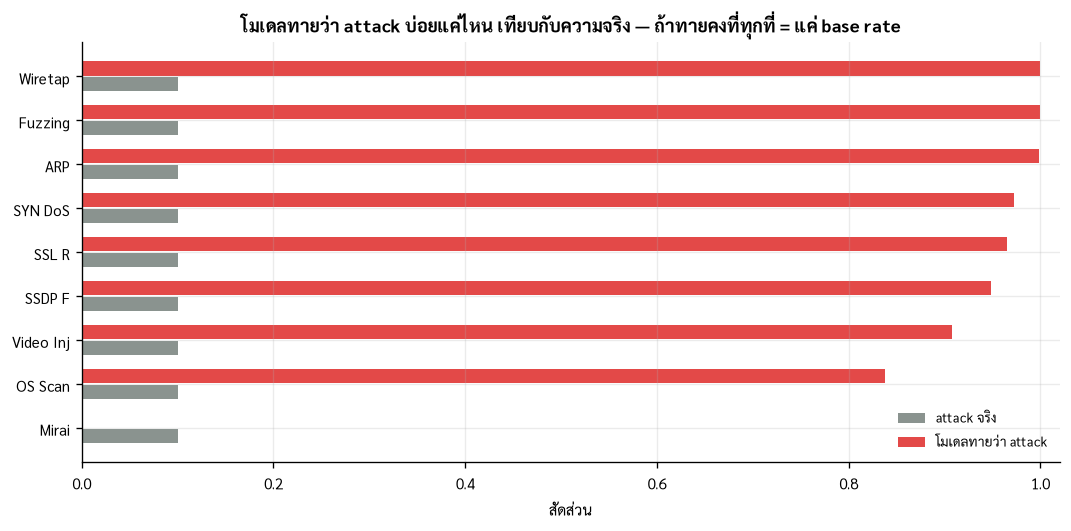

ช่วงกว้างของสัดส่วนที่โมเดลทายว่า attack ระหว่างสถานการณ์: 0.999
ถ้าเป็นแค่ผล class imbalance (โมเดลทายทางเดียวคงที่) ช่วงนี้ควรใกล้ 0


In [27]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(ppr))
ax.barh(y - 0.18, ppr["สัดส่วน attack จริง"], height=0.32, color=C["grey"], label="attack จริง")
ax.barh(y + 0.18, ppr["สัดส่วนที่โมเดลทายว่า attack"], height=0.32, color=C["red"],
       label="โมเดลทายว่า attack")
ax.set_yticks(y, ppr["scenario"])
ax.set_xlim(0, 1.02)
ax.set_xlabel("สัดส่วน")
ax.set_title("โมเดลทายว่า attack บ่อยแค่ไหน เทียบกับความจริง — ถ้าทายคงที่ทุกที่ = แค่ base rate")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

spread = ppr["สัดส่วนที่โมเดลทายว่า attack"].max() - ppr["สัดส่วนที่โมเดลทายว่า attack"].min()
print(f"ช่วงกว้างของสัดส่วนที่โมเดลทายว่า attack ระหว่างสถานการณ์: {spread:.3f}")
print("ถ้าเป็นแค่ผล class imbalance (โมเดลทายทางเดียวคงที่) ช่วงนี้ควรใกล้ 0")

### อ่านผลข้อ 3.4

ถ้าสัดส่วนที่โมเดลทายว่า "attack" **แกว่งกว้างระหว่างสถานการณ์** (เช่น Mirai ทายว่า attack น้อย
แต่ ARP/SSL R ทายว่า attack เกือบทั้งหมด) แปลว่า **โมเดลตอบสนองต่ออินพุตจริง ไม่ใช่ทายทางเดียวคงที่**
ผลที่แย่จึงไม่ใช่เพราะ class imbalance ล้วน ๆ แต่เป็นเพราะโมเดลเห็นอินพุตของ Kitsune แต่ละสถานการณ์
แล้ว "เข้าใจผิด" ไปคนละทิศคนละทาง — ยิ่งสนับสนุนว่าเป็น domain shift จริง ไม่ใช่บั๊กจาก imbalance

ถ้าตรงข้าม (สัดส่วนคงที่เกือบเดียวกันทุกสถานการณ์ ใกล้เคียงสัดส่วน attack ในชุดเทรน) แปลว่า
โมเดลอาจจะทายทางเดียวจริง ต้องแก้ class imbalance ก่อนสรุปอะไรเพิ่ม

---

## 3.5 แก้ class imbalance ด้วย `class_weight="balanced"` แล้ว AUC ดีขึ้นไหม

`class_weight="balanced"` ปรับน้ำหนักตอนเทรนให้สองคลาสมีอิทธิพลเท่ากัน (ไม่ให้ attack ที่มีเยอะกว่า
ครอบงำการเรียนรู้) ถ้าเป็นปัญหา imbalance ล้วน ๆ ตัวนี้ควรช่วยให้ AUC ดีขึ้นชัดเจน
แต่ AUC เป็นค่าที่ไม่ขึ้นกับจุดตัดสินใจ (threshold-independent) ถ้าปัญหาจริงคือโมเดลจัดอันดับ
attack/benign ของ Kitsune ไม่ได้เลย (ไม่ใช่แค่จุดตัดเพี้ยน) `class_weight` จะช่วยได้จำกัดมาก

In [28]:
transfer_clf_balanced = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1,
                                               random_state=42, class_weight="balanced")
transfer_clf_balanced.fit(transfer_scaler.transform(Xfull), yfull)

balanced_rows = []
for scenario, (_, test) in kit_data.items():
    test_c = clip_pcc_columns(test, FEATURE_COLS)
    Xte = test_c[FEATURE_COLS].to_numpy(dtype=float)
    yte = test_c["label"].to_numpy()
    pred = transfer_clf_balanced.predict(transfer_scaler.transform(Xte))
    proba = transfer_clf_balanced.predict_proba(transfer_scaler.transform(Xte))[:, 1]
    balanced_rows.append({
        "scenario": scenario,
        "accuracy": round(accuracy_score(yte, pred), 4),
        "auc": round(roc_auc_score(yte, proba), 4) if len(set(yte)) > 1 else np.nan,
    })
transfer_balanced = pd.DataFrame(balanced_rows)

final_compare = pd.DataFrame([
    {"รุ่นโมเดล": "2.4 เดิม (class_weight=None)",
     "accuracy เฉลี่ย": transfer_results["accuracy"].mean(), "AUC เฉลี่ย": transfer_results["auc"].mean()},
    {"รุ่นโมเดล": "2.5 scaler ปรับใหม่ต่อสถานการณ์",
     "accuracy เฉลี่ย": transfer_v2["accuracy"].mean(), "AUC เฉลี่ย": transfer_v2["auc"].mean()},
    {"รุ่นโมเดล": "3.3 สุ่มตัวอย่างแบบสุ่มจริง",
     "accuracy เฉลี่ย": transfer_random["accuracy"].mean(), "AUC เฉลี่ย": transfer_random["auc"].mean()},
    {"รุ่นโมเดล": "3.5 class_weight=balanced",
     "accuracy เฉลี่ย": transfer_balanced["accuracy"].mean(), "AUC เฉลี่ย": transfer_balanced["auc"].mean()},
]).round(4)
final_compare

,รุ่นโมเดล,accuracy เฉลี่ย,AUC เฉลี่ย
0,2.4 เดิม (class_weight=None),0.2173,0.4480
1,2.5 scaler ปรับใหม่ต่อสถานการณ์,0.3688,0.4622
2,3.3 สุ่มตัวอย่างแบบสุ่มจริง,0.1891,0.4326
3,3.5 class_weight=balanced,0.1890,0.4549


## 3.6 สรุปการตรวจสอบ

ผลข้อ 2.4 ผ่านการตรวจสอบห้าข้อ: ข้อมูลดิบถูกต้องตรงกับเอกสารต้นทาง · ฟีเจอร์ตรงตำแหน่งกันจริง
(ยืนยันซ้ำในเซสชันนี้) · การสุ่มตัวอย่างแบบ `nrows=` ให้ผลไม่ต่างจากการสุ่มจริง ·
โมเดลไม่ได้ทายทางเดียวคงที่ (สัดส่วนทายว่า attack แกว่งไปตามแต่ละสถานการณ์จริง) ·
และการแก้ class imbalance ด้วย `class_weight="balanced"` ไม่ได้ทำให้ AUC ดีขึ้นอย่างมีนัยสำคัญ

**บทสรุปเดิมยังยืนได้:** ตัวเลข AUC ~0.45 บน Kitsune ไม่ใช่ผลจากบั๊กในไปป์ไลน์หรือวิธีสุ่มตัวอย่าง
แต่เป็นข้อค้นพบจริงที่ว่า **โมเดลที่เทรนจาก N-BaIoT ไม่สามารถแยกแยะ benign/attack ของ Kitsune ได้เลย
แม้ฟีเจอร์จะอยู่ในตำแหน่งเดียวกันเป๊ะก็ตาม** — "ฟีเจอร์ตรงตำแหน่งกัน" ยังคงเป็นเงื่อนไขจำเป็นแต่ไม่พอ
สำหรับการโอนโมเดลข้าม dataset ตามที่สรุปไว้ในตอนแรก ข้อสรุปนี้ตอนนี้ผ่านการตรวจสอบแล้ว ไม่ใช่แค่
ตัวเลขที่เห็นครั้งแรกแล้วเชื่อตาม